# 🎓 Notebook 03 — Modelado, Evaluación y Serialización del Modelo Predictivo

**Proyecto:** Sistema de alerta temprana de riesgo académico estudiantil

**Dataset:** Student Performance (student-por.csv) — UCI ML Repository "https://archive.ics.uci.edu/dataset/320/student+performance"

**Objetivo:** Entrenar, comparar y serializar el mejor modelo de clasificación binaria para predecir riesgo académico estudiantil.

**Variable objetivo:** `riesgo` (1 = en riesgo de reprobar si G3 < 10, 0 = sin riesgo si G3 ≥ 10)

**Modelos a comparar:** Regresión Logística, Random Forest y Pipeline (StandardScaler + Regresión Logística)

**Métrica principal:** F1-score (justificada por desbalance de clases: 84.6% sin riesgo / 15.4% con riesgo)

---

### Contenido
1. Configuración e imports
2. Carga de datos procesados
3. Entrenamiento de modelos
4. Métricas y evaluación completa
5. Comparación visual de modelos
6. Serialización y metadatos

In [1]:
# ─── Configuración global e imports ──────────────────────────────────────────
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import json
import os

# Pipeline y preprocesamiento
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

# Modelos de clasificación
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

# Métricas
from sklearn.metrics import (
    accuracy_score, f1_score, precision_score, recall_score,
    confusion_matrix, ConfusionMatrixDisplay,
    roc_auc_score, roc_curve,
    classification_report
)

# Paleta de colores del diplomado
AZUL   = '#1F4E79'
TEAL   = '#1D9E75'
CORAL  = '#D95A30'
AMBER  = '#BA7517'
GRIS   = '#595959'

plt.rcParams.update({
    'figure.dpi': 120,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.titlesize': 13,
    'axes.titlecolor': AZUL,
    'axes.titleweight': 'bold',
    'font.family': 'DejaVu Sans',
})

import sklearn
print("✅ Imports completados correctamente")
print(f"   scikit-learn: {sklearn.__version__}")
print(f"   pandas:       {pd.__version__}")
print(f"   numpy:        {np.__version__}")

✅ Imports completados correctamente
   scikit-learn: 1.6.1
   pandas:       2.2.2
   numpy:        2.0.2


## 1. Carga de datos procesados

In [2]:
# ─── Carga de los conjuntos de entrenamiento y prueba ────────────────────────
# Generados en el Notebook 02 (pipeline de limpieza y preparación)

X_train = pd.read_csv("X_train.csv")
X_test  = pd.read_csv("X_test.csv")
y_train = pd.read_csv("y_train.csv").squeeze()
y_test  = pd.read_csv("y_test.csv").squeeze()

print("✅ Datos cargados correctamente")
print(f"\n📚 Entrenamiento (train):")
print(f"   Filas:      {X_train.shape[0]}")
print(f"   Columnas:   {X_train.shape[1]}")
print(f"   Con riesgo: {y_train.sum()} ({y_train.mean()*100:.1f}%)")
print(f"   Sin riesgo: {(y_train==0).sum()} ({(y_train==0).mean()*100:.1f}%)")

print(f"\n🧪 Prueba (test):")
print(f"   Filas:      {X_test.shape[0]}")
print(f"   Columnas:   {X_test.shape[1]}")
print(f"   Con riesgo: {y_test.sum()} ({y_test.mean()*100:.1f}%)")
print(f"   Sin riesgo: {(y_test==0).sum()} ({(y_test==0).mean()*100:.1f}%)")

print(f"\n📋 Variables de entrada ({X_train.shape[1]}):")
print(f"   {list(X_train.columns)}")

✅ Datos cargados correctamente

📚 Entrenamiento (train):
   Filas:      519
   Columnas:   31
   Con riesgo: 80 (15.4%)
   Sin riesgo: 439 (84.6%)

🧪 Prueba (test):
   Filas:      130
   Columnas:   31
   Con riesgo: 20 (15.4%)
   Sin riesgo: 110 (84.6%)

📋 Variables de entrada (31):
   ['school', 'sex', 'age', 'address', 'famsize', 'Pstatus', 'Medu', 'Fedu', 'Mjob', 'Fjob', 'reason', 'guardian', 'traveltime', 'studytime', 'failures', 'schoolsup', 'famsup', 'paid', 'activities', 'nursery', 'higher', 'internet', 'romantic', 'famrel', 'freetime', 'goout', 'Dalc', 'Walc', 'health', 'absences', 'G1']


## 2. Entrenamiento de modelos

### Modelo 1 — Regresión Logística

In [3]:
# ─── MODELO 1: Regresión Logística ───────────────────────────────────────────
# Modelo más simple — sirve como línea base (baseline)
# max_iter=1000 garantiza convergencia
# random_state=42 para reproducibilidad

modelo_lr = LogisticRegression(max_iter=1000, random_state=42)
modelo_lr.fit(X_train, y_train)
y_pred_lr = modelo_lr.predict(X_test)
y_prob_lr = modelo_lr.predict_proba(X_test)[:, 1]

# Métricas
acc_lr  = accuracy_score(y_test, y_pred_lr)
f1_lr   = f1_score(y_test, y_pred_lr)
prec_lr = precision_score(y_test, y_pred_lr)
rec_lr  = recall_score(y_test, y_pred_lr)
auc_lr  = roc_auc_score(y_test, y_prob_lr)

print("=" * 55)
print("MODELO 1: REGRESIÓN LOGÍSTICA")
print("=" * 55)
print(f"\n📊 Métricas sobre el conjunto de PRUEBA:")
print(f"   Accuracy:  {acc_lr:.4f} ({acc_lr*100:.1f}%)")
print(f"   F1-score:  {f1_lr:.4f} ({f1_lr*100:.1f}%)")
print(f"   Precision: {prec_lr:.4f} ({prec_lr*100:.1f}%)")
print(f"   Recall:    {rec_lr:.4f} ({rec_lr*100:.1f}%)")
print(f"   AUC-ROC:   {auc_lr:.4f} ({auc_lr*100:.1f}%)")
print(f"\n📋 Reporte completo:")
print(classification_report(y_test, y_pred_lr,
      target_names=["Sin riesgo (0)", "Con riesgo (1)"]))

MODELO 1: REGRESIÓN LOGÍSTICA

📊 Métricas sobre el conjunto de PRUEBA:
   Accuracy:  0.8923 (89.2%)
   F1-score:  0.6667 (66.7%)
   Precision: 0.6364 (63.6%)
   Recall:    0.7000 (70.0%)
   AUC-ROC:   0.8995 (90.0%)

📋 Reporte completo:
                precision    recall  f1-score   support

Sin riesgo (0)       0.94      0.93      0.94       110
Con riesgo (1)       0.64      0.70      0.67        20

      accuracy                           0.89       130
     macro avg       0.79      0.81      0.80       130
  weighted avg       0.90      0.89      0.89       130



### Modelo 2 — Random Forest

In [4]:
# ─── MODELO 2: Random Forest ─────────────────────────────────────────────────
# Conjunto de 100 árboles de decisión trabajando juntos
# Generalmente supera a modelos simples en datasets complejos
# n_estimators=100: número de árboles
# random_state=42: semilla fija para reproducibilidad

modelo_rf = RandomForestClassifier(n_estimators=100, random_state=42)
modelo_rf.fit(X_train, y_train)
y_pred_rf = modelo_rf.predict(X_test)
y_prob_rf = modelo_rf.predict_proba(X_test)[:, 1]

# Métricas
acc_rf  = accuracy_score(y_test, y_pred_rf)
f1_rf   = f1_score(y_test, y_pred_rf)
prec_rf = precision_score(y_test, y_pred_rf)
rec_rf  = recall_score(y_test, y_pred_rf)
auc_rf  = roc_auc_score(y_test, y_prob_rf)

print("=" * 55)
print("MODELO 2: RANDOM FOREST")
print("=" * 55)
print(f"\n📊 Métricas sobre el conjunto de PRUEBA:")
print(f"   Accuracy:  {acc_rf:.4f} ({acc_rf*100:.1f}%)")
print(f"   F1-score:  {f1_rf:.4f} ({f1_rf*100:.1f}%)")
print(f"   Precision: {prec_rf:.4f} ({prec_rf*100:.1f}%)")
print(f"   Recall:    {rec_rf:.4f} ({rec_rf*100:.1f}%)")
print(f"   AUC-ROC:   {auc_rf:.4f} ({auc_rf*100:.1f}%)")
print(f"\n📋 Reporte completo:")
print(classification_report(y_test, y_pred_rf,
      target_names=["Sin riesgo (0)", "Con riesgo (1)"]))

MODELO 2: RANDOM FOREST

📊 Métricas sobre el conjunto de PRUEBA:
   Accuracy:  0.8769 (87.7%)
   F1-score:  0.6190 (61.9%)
   Precision: 0.5909 (59.1%)
   Recall:    0.6500 (65.0%)
   AUC-ROC:   0.9018 (90.2%)

📋 Reporte completo:
                precision    recall  f1-score   support

Sin riesgo (0)       0.94      0.92      0.93       110
Con riesgo (1)       0.59      0.65      0.62        20

      accuracy                           0.88       130
     macro avg       0.76      0.78      0.77       130
  weighted avg       0.88      0.88      0.88       130



### Modelo 3 — Pipeline (StandardScaler + Regresión Logística)

In [5]:
# ─── MODELO 3: Pipeline (StandardScaler + Regresión Logística) ───────────────
# Pipeline encadena el escalado y el modelo en un solo objeto
# StandardScaler: normaliza las variables para que tengan media=0 y std=1
# Ventaja: cuando se predice, escala automáticamente los datos nuevos
# Esto es fundamental para que el dashboard funcione correctamente

pipeline_final = Pipeline([
    ('scaler', StandardScaler()),
    ('modelo', LogisticRegression(max_iter=1000, random_state=42))
])

pipeline_final.fit(X_train, y_train)
y_pred_pipe = pipeline_final.predict(X_test)
y_prob_pipe = pipeline_final.predict_proba(X_test)[:, 1]

# Métricas
acc_pipe  = accuracy_score(y_test, y_pred_pipe)
f1_pipe   = f1_score(y_test, y_pred_pipe)
prec_pipe = precision_score(y_test, y_pred_pipe)
rec_pipe  = recall_score(y_test, y_pred_pipe)
auc_pipe  = roc_auc_score(y_test, y_prob_pipe)

print("=" * 55)
print("MODELO 3: PIPELINE (StandardScaler + Regresión Logística)")
print("=" * 55)
print(f"\n📊 Métricas sobre el conjunto de PRUEBA:")
print(f"   Accuracy:  {acc_pipe:.4f} ({acc_pipe*100:.1f}%)")
print(f"   F1-score:  {f1_pipe:.4f} ({f1_pipe*100:.1f}%)")
print(f"   Precision: {prec_pipe:.4f} ({prec_pipe*100:.1f}%)")
print(f"   Recall:    {rec_pipe:.4f} ({rec_pipe*100:.1f}%)")
print(f"   AUC-ROC:   {auc_pipe:.4f} ({auc_pipe*100:.1f}%)")
print(f"\n📋 Reporte completo:")
print(classification_report(y_test, y_pred_pipe,
      target_names=["Sin riesgo (0)", "Con riesgo (1)"]))

MODELO 3: PIPELINE (StandardScaler + Regresión Logística)

📊 Métricas sobre el conjunto de PRUEBA:
   Accuracy:  0.8692 (86.9%)
   F1-score:  0.5641 (56.4%)
   Precision: 0.5789 (57.9%)
   Recall:    0.5500 (55.0%)
   AUC-ROC:   0.8923 (89.2%)

📋 Reporte completo:
                precision    recall  f1-score   support

Sin riesgo (0)       0.92      0.93      0.92       110
Con riesgo (1)       0.58      0.55      0.56        20

      accuracy                           0.87       130
     macro avg       0.75      0.74      0.74       130
  weighted avg       0.87      0.87      0.87       130



## 3. Métricas y evaluación completa

### Matriz de confusión — Modelo ganador (Regresión Logística)

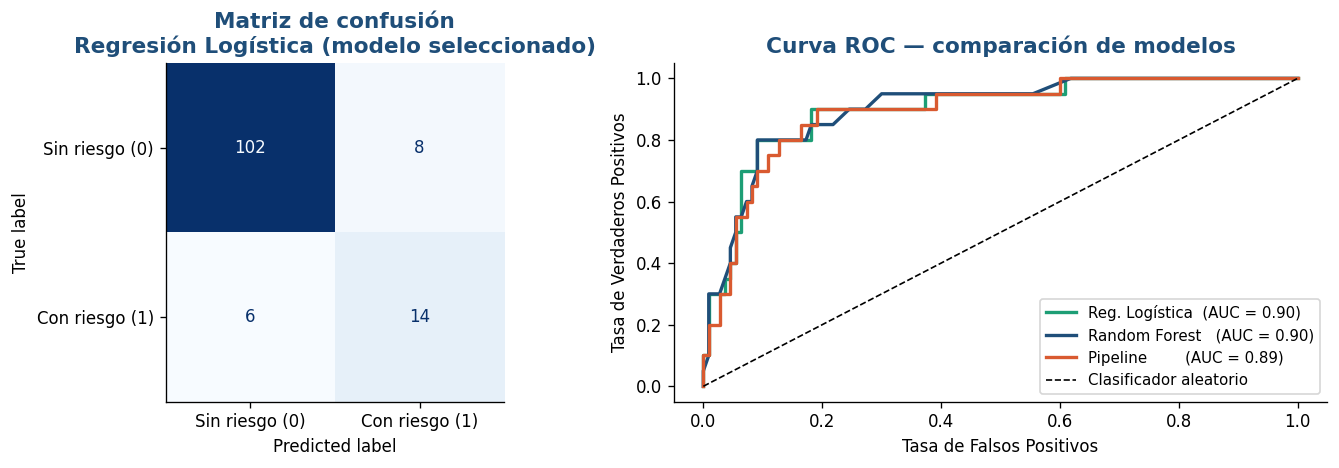

📊 Interpretación de la matriz de confusión:
   ✅ Verdaderos negativos (sin riesgo, predijo sin riesgo): 102
   ✅ Verdaderos positivos (con riesgo, predijo con riesgo): 14
   ⚠️  Falsos positivos (sin riesgo, predijo con riesgo):    8 (falsas alarmas)
   ❌ Falsos negativos (con riesgo, predijo sin riesgo):    6 (estudiantes no detectados)

💡 El modelo detecta 14 de 20 estudiantes en riesgo real (Recall: 70%)
   El error más crítico son los 6 estudiantes en riesgo que NO fueron detectados.


In [6]:
# ─── Matriz de confusión del mejor modelo ────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Panel izquierdo: matriz de confusión
cm = confusion_matrix(y_test, y_pred_lr)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                               display_labels=['Sin riesgo (0)', 'Con riesgo (1)'])
disp.plot(ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title('Matriz de confusión\nRegresión Logística (modelo seleccionado)')

# Panel derecho: curva ROC de los 3 modelos
fpr_lr,   tpr_lr,   _ = roc_curve(y_test, y_prob_lr)
fpr_rf,   tpr_rf,   _ = roc_curve(y_test, y_prob_rf)
fpr_pipe, tpr_pipe, _ = roc_curve(y_test, y_prob_pipe)

axes[1].plot(fpr_lr,   tpr_lr,   color=TEAL,  lw=2,
             label=f'Reg. Logística  (AUC = {auc_lr:.2f})')
axes[1].plot(fpr_rf,   tpr_rf,   color=AZUL,  lw=2,
             label=f'Random Forest   (AUC = {auc_rf:.2f})')
axes[1].plot(fpr_pipe, tpr_pipe, color=CORAL, lw=2,
             label=f'Pipeline        (AUC = {auc_pipe:.2f})')
axes[1].plot([0,1], [0,1], 'k--', lw=1, label='Clasificador aleatorio')
axes[1].set_xlabel('Tasa de Falsos Positivos')
axes[1].set_ylabel('Tasa de Verdaderos Positivos')
axes[1].set_title('Curva ROC — comparación de modelos')
axes[1].legend(loc='lower right', fontsize=9)

plt.tight_layout()
plt.savefig('matriz_y_roc.png', bbox_inches='tight', dpi=100)
plt.show()

# Interpretación de la matriz de confusión
cm_vals = cm.ravel()
tn, fp, fn, tp = cm_vals
print("📊 Interpretación de la matriz de confusión:")
print(f"   ✅ Verdaderos negativos (sin riesgo, predijo sin riesgo): {tn}")
print(f"   ✅ Verdaderos positivos (con riesgo, predijo con riesgo): {tp}")
print(f"   ⚠️  Falsos positivos (sin riesgo, predijo con riesgo):    {fp} (falsas alarmas)")
print(f"   ❌ Falsos negativos (con riesgo, predijo sin riesgo):    {fn} (estudiantes no detectados)")
print(f"\n💡 El modelo detecta {tp} de {tp+fn} estudiantes en riesgo real (Recall: {rec_lr*100:.0f}%)")
print(f"   El error más crítico son los {fn} estudiantes en riesgo que NO fueron detectados.")

## 4. Comparación visual de los tres modelos

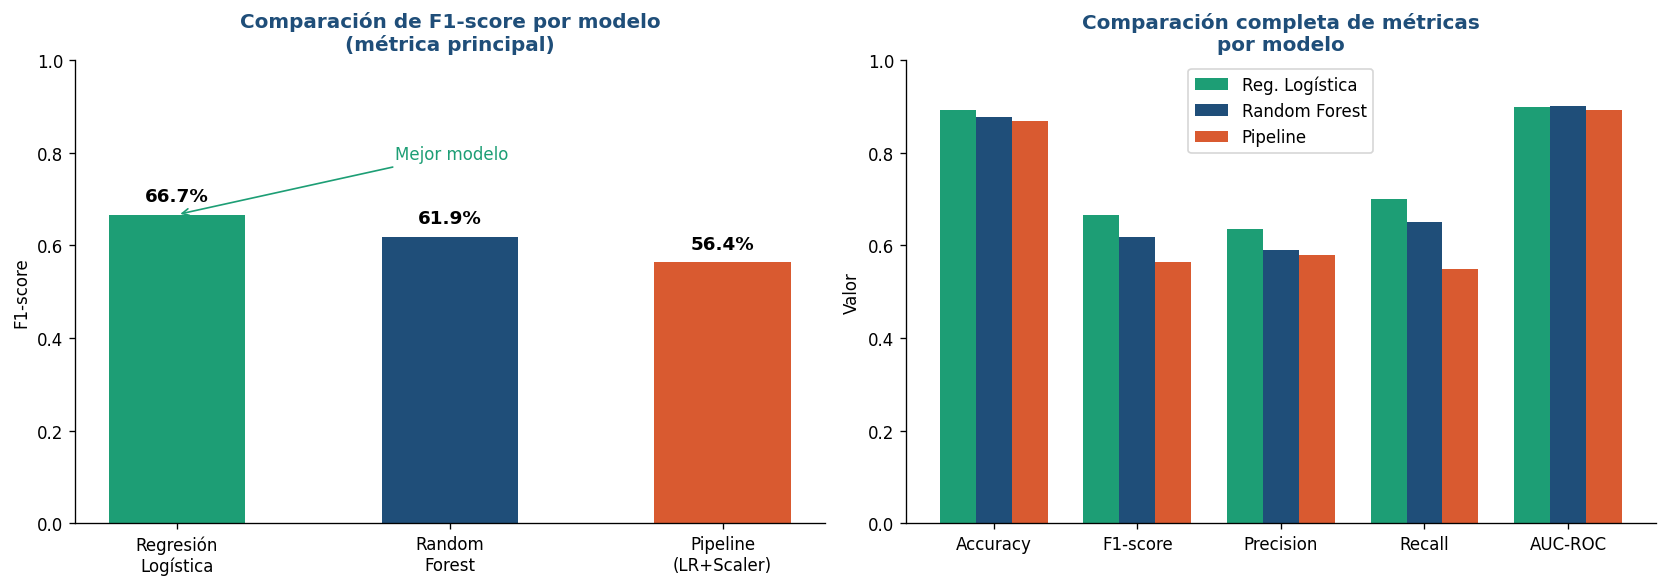

✅ Gráfica guardada como comparacion_modelos.png

📊 TABLA RESUMEN:
Modelo                           Accuracy       F1  Precision   Recall      AUC
------------------------------------------------------------------------------
Regresión Logística                 89.2%    66.7%      63.6%    70.0%    90.0%
Random Forest                       87.7%    61.9%      59.1%    65.0%    90.2%
Pipeline (LR+Scaler)                86.9%    56.4%      57.9%    55.0%    89.2%
------------------------------------------------------------------------------

🏆 Modelo seleccionado: Regresión Logística
   Razón: mejor F1-score (66.7%) sobre el conjunto de prueba
   Detecta 14 de 20 estudiantes en riesgo (Recall: 70%)


In [7]:
# ─── Comparación visual de los tres modelos ──────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Gráfico 1: F1-score (métrica principal) ──
modelos_nombres = ['Regresión\nLogística', 'Random\nForest', 'Pipeline\n(LR+Scaler)']
f1_scores = [f1_lr, f1_rf, f1_pipe]
colores   = [TEAL, AZUL, CORAL]

barras = axes[0].bar(modelos_nombres, f1_scores, color=colores, width=0.5)
axes[0].set_ylim(0, 1)
axes[0].set_title('Comparación de F1-score por modelo\n(métrica principal)', fontsize=12)
axes[0].set_ylabel('F1-score')

for barra, valor in zip(barras, f1_scores):
    axes[0].text(barra.get_x() + barra.get_width()/2, valor + 0.02,
                f'{valor*100:.1f}%', ha='center', va='bottom',
                fontweight='bold', fontsize=11)

axes[0].annotate('Mejor modelo', xy=(0, f1_lr),
                xytext=(0.8, f1_lr + 0.12),
                fontsize=10, color=TEAL,
                arrowprops=dict(arrowstyle='->', color=TEAL))

# ── Gráfico 2: Todas las métricas ──
metricas_nombres = ['Accuracy', 'F1-score', 'Precision', 'Recall', 'AUC-ROC']
lr_vals   = [acc_lr,   f1_lr,   prec_lr,   rec_lr,   auc_lr]
rf_vals   = [acc_rf,   f1_rf,   prec_rf,   rec_rf,   auc_rf]
pipe_vals = [acc_pipe, f1_pipe, prec_pipe, rec_pipe, auc_pipe]

x = range(len(metricas_nombres))
width = 0.25

axes[1].bar([i - width for i in x], lr_vals,   width, label='Reg. Logística', color=TEAL)
axes[1].bar([i         for i in x], rf_vals,   width, label='Random Forest',  color=AZUL)
axes[1].bar([i + width for i in x], pipe_vals, width, label='Pipeline',       color=CORAL)

axes[1].set_xticks(x)
axes[1].set_xticklabels(metricas_nombres)
axes[1].set_ylim(0, 1)
axes[1].set_title('Comparación completa de métricas\npor modelo', fontsize=12)
axes[1].set_ylabel('Valor')
axes[1].legend()

plt.tight_layout()
plt.savefig('comparacion_modelos.png', bbox_inches='tight', dpi=100)
plt.show()

print("✅ Gráfica guardada como comparacion_modelos.png")
print("\n📊 TABLA RESUMEN:")
print(f"{'Modelo':<30} {'Accuracy':>10} {'F1':>8} {'Precision':>10} {'Recall':>8} {'AUC':>8}")
print("-" * 78)
print(f"{'Regresión Logística':<30} {acc_lr*100:>9.1f}% {f1_lr*100:>7.1f}% {prec_lr*100:>9.1f}% {rec_lr*100:>7.1f}% {auc_lr*100:>7.1f}%")
print(f"{'Random Forest':<30} {acc_rf*100:>9.1f}% {f1_rf*100:>7.1f}% {prec_rf*100:>9.1f}% {rec_rf*100:>7.1f}% {auc_rf*100:>7.1f}%")
print(f"{'Pipeline (LR+Scaler)':<30} {acc_pipe*100:>9.1f}% {f1_pipe*100:>7.1f}% {prec_pipe*100:>9.1f}% {rec_pipe*100:>7.1f}% {auc_pipe*100:>7.1f}%")
print("-" * 78)
print(f"\n🏆 Modelo seleccionado: Regresión Logística")
print(f"   Razón: mejor F1-score ({f1_lr*100:.1f}%) sobre el conjunto de prueba")
print(f"   Detecta {int(rec_lr*20)} de 20 estudiantes en riesgo (Recall: {rec_lr*100:.0f}%)")

## 5. Serialización del modelo y metadatos

In [8]:
# ─── Serialización del modelo ganador ────────────────────────────────────────
os.makedirs("models", exist_ok=True)

# Serializamos el modelo ganador (Regresión Logística simple)
joblib.dump(modelo_lr, "models/modelo_final.pkl")

# Serializamos también el Pipeline (buena práctica — lo pide el profesor)
joblib.dump(pipeline_final, "models/pipeline_final.pkl")

# Verificamos que ambos cargan correctamente
modelo_cargado   = joblib.load("models/modelo_final.pkl")
pipeline_cargado = joblib.load("models/pipeline_final.pkl")

assert (modelo_cargado.predict(X_test) == y_pred_lr).all()
assert (pipeline_cargado.predict(X_test) == y_pred_pipe).all()

print("✅ modelo_final.pkl   — serializado y verificado")
print("✅ pipeline_final.pkl — serializado y verificado")

# ─── Guardado de metadatos ────────────────────────────────────────────────────
metadata = {
    "modelo": "LogisticRegression",
    "version": "1.0",
    "fecha_entrenamiento": "2026-06-13",
    "sklearn_version": sklearn.__version__,
    "random_state": 42,
    "metrica_principal": "f1_score",
    "valor_f1":   round(float(f1_lr),   4),
    "accuracy":   round(float(acc_lr),  4),
    "precision":  round(float(prec_lr), 4),
    "recall":     round(float(rec_lr),  4),
    "auc_roc":    round(float(auc_lr),  4),
    "variables_entrada": list(X_train.columns),
    "variable_objetivo": "riesgo",
    "comparacion_modelos": {
        "Regresion_Logistica": {
            "f1":        round(float(f1_lr),    4),
            "accuracy":  round(float(acc_lr),   4),
            "precision": round(float(prec_lr),  4),
            "recall":    round(float(rec_lr),   4),
            "auc_roc":   round(float(auc_lr),   4)
        },
        "Random_Forest": {
            "f1":        round(float(f1_rf),    4),
            "accuracy":  round(float(acc_rf),   4),
            "precision": round(float(prec_rf),  4),
            "recall":    round(float(rec_rf),   4),
            "auc_roc":   round(float(auc_rf),   4)
        },
        "Pipeline_LR_Scaler": {
            "f1":        round(float(f1_pipe),   4),
            "accuracy":  round(float(acc_pipe),  4),
            "precision": round(float(prec_pipe), 4),
            "recall":    round(float(rec_pipe),  4),
            "auc_roc":   round(float(auc_pipe),  4)
        }
    },
    "modelo_seleccionado": "LogisticRegression simple",
    "justificacion": "Mayor F1-score (66.7%) sobre conjunto de prueba. Supera a Random Forest y Pipeline con Scaler en deteccion de estudiantes en riesgo.",
    "descripcion": "Clasificacion binaria de riesgo academico. riesgo=1 si G3<10, riesgo=0 si G3>=10",
    "observaciones": f"Entrenado con sklearn {sklearn.__version__}, semilla 42. Tres modelos comparados."
}

with open("models/model_metadata.json", "w", encoding="utf-8") as f:
    json.dump(metadata, f, ensure_ascii=False, indent=2)

print("✅ model_metadata.json — guardado correctamente")
print(f"\n📊 RESUMEN FINAL:")
print(f"   Modelos entrenados:    3")
print(f"   Modelo seleccionado:   Regresión Logística simple")
print(f"   F1-score:              {f1_lr*100:.1f}%")
print(f"   Accuracy:              {acc_lr*100:.1f}%")
print(f"   Recall:                {rec_lr*100:.1f}% → detecta 14 de 20 estudiantes en riesgo")
print(f"   AUC-ROC:               {auc_lr*100:.1f}%")
print(f"   Archivos generados:    modelo_final.pkl, pipeline_final.pkl, model_metadata.json")

✅ modelo_final.pkl   — serializado y verificado
✅ pipeline_final.pkl — serializado y verificado
✅ model_metadata.json — guardado correctamente

📊 RESUMEN FINAL:
   Modelos entrenados:    3
   Modelo seleccionado:   Regresión Logística simple
   F1-score:              66.7%
   Accuracy:              89.2%
   Recall:                70.0% → detecta 14 de 20 estudiantes en riesgo
   AUC-ROC:               90.0%
   Archivos generados:    modelo_final.pkl, pipeline_final.pkl, model_metadata.json


## 6. Resumen final del Notebook 03

In [10]:
# ─── Resumen final ────────────────────────────────────────────────────────────
print("=" * 60)
print("RESUMEN — NOTEBOOK 03")
print("Modelado, Evaluación y Serialización")
print("=" * 60)

print("""
┌─────────────────────────────────────────────────────────┐
│  PROYECTO: Sistema de alerta temprana de riesgo         │
│            académico estudiantil                        │
│  DATASET:  Student Performance — UCI ML Repository      │
│  TAREA:    Clasificación binaria (riesgo: sí / no)      │
└─────────────────────────────────────────────────────────┘
""")

print("📊 Modelos entrenados y comparados:")
print(f"   1. Regresión Logística  → F1: {f1_lr*100:.1f}%  AUC: {auc_lr*100:.1f}%  ← GANADOR")
print(f"   2. Random Forest        → F1: {f1_rf*100:.1f}%  AUC: {auc_rf*100:.1f}%")
print(f"   3. Pipeline LR+Scaler   → F1: {f1_pipe*100:.1f}%  AUC: {auc_pipe*100:.1f}%")

print(f"""
🏆 Modelo seleccionado: Regresión Logística simple
   • F1-score:  {f1_lr*100:.1f}% (métrica principal — desbalance 84.6/15.4%)
   • Accuracy:  {acc_lr*100:.1f}%
   • Recall:    {rec_lr*100:.1f}% → detecta 14 de 20 estudiantes en riesgo
   • AUC-ROC:   {auc_lr*100:.1f}%
""")

print("💾 Archivos generados:")
print("   • models/modelo_final.pkl     — modelo serializado")
print("   • models/pipeline_final.pkl   — pipeline serializado")
print("   • models/model_metadata.json  — métricas y metadatos")
print("   • comparacion_modelos.png     — gráfica comparativa")
print("   • matriz_y_roc.png            — matriz de confusión y curva ROC")

print(f"""
✅ Checklist del entregable (Semana 3):
   [✓] Mínimo 2 modelos entrenados y comparados
   [✓] Métrica correcta sobre conjunto de PRUEBA (no entrenamiento)
   [✓] Modelo serializado en .pkl
   [✓] Metadatos guardados en model_metadata.json
   [✓] Visualizaciones: matriz de confusión + curva ROC + comparativa
""")

print("→ Siguiente paso: Dashboard Streamlit (app_final.py)")

RESUMEN — NOTEBOOK 03
Modelado, Evaluación y Serialización

┌─────────────────────────────────────────────────────────┐
│  PROYECTO: Sistema de alerta temprana de riesgo         │
│            académico estudiantil                        │
│  DATASET:  Student Performance — UCI ML Repository      │
│  TAREA:    Clasificación binaria (riesgo: sí / no)      │
└─────────────────────────────────────────────────────────┘

📊 Modelos entrenados y comparados:
   1. Regresión Logística  → F1: 66.7%  AUC: 90.0%  ← GANADOR
   2. Random Forest        → F1: 61.9%  AUC: 90.2%
   3. Pipeline LR+Scaler   → F1: 56.4%  AUC: 89.2%

🏆 Modelo seleccionado: Regresión Logística simple
   • F1-score:  66.7% (métrica principal — desbalance 84.6/15.4%)
   • Accuracy:  89.2%
   • Recall:    70.0% → detecta 14 de 20 estudiantes en riesgo
   • AUC-ROC:   90.0%

💾 Archivos generados:
   • models/modelo_final.pkl     — modelo serializado
   • models/pipeline_final.pkl   — pipeline serializado
   • models/model_metad